# 🏦 Banking Customer Segmentation Using K-Means Clustering

### Machine Learning Project | Unsupervised Learning

This project uses K-Means Clustering to segment banking customers based on their financial and behavioural characteristics.

### Key Features Used
- Annual Income
- Account Balance
- Credit Score
- Transactions Per Month
- Loan Amount
- Monthly Spending

### Objective
To identify meaningful customer groups that can help banks understand customer behaviour and support data-driven customer segmentation.

## 📌 Project Overview

Customer segmentation is an important task in the banking industry.

In this project, K-Means Clustering is used to group customers with similar financial and behavioural characteristics.

The clustering process helps identify different customer segments based on income, account balance, transactions, loan amount, and monthly spending.

## 💼 Business Problem

Banks have customers with different financial behaviours.

It can be difficult to treat all customers in the same way. By using customer segmentation,
banks can identify groups of customers with similar characteristics.

This project aims to discover these customer groups using an unsupervised machine learning approach.

## 🎯 Project Objectives

- Understand the banking customer dataset.
- Perform data quality checks.
- Explore customer financial behaviour.
- Select relevant features for clustering.
- Scale the selected features.
- Determine the appropriate number of clusters.
- Apply K-Means Clustering.
- Analyse and interpret the resulting customer segments.
- Save the trained model for future predictions.

## 📚 Import Required Libraries

The required Python libraries are imported for data manipulation, visualization, preprocessing, and K-Means clustering.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 📂 Load Dataset

The banking customer dataset is loaded using Pandas for further analysis and preprocessing.

In [3]:
df = pd.read_csv("../data/banking_customer_segmentation_raw_data.csv")

df.head()

,Customer_ID,Age,Annual_Income,Account_Balance,Credit_Score,Transactions_Per_Month,Loan_Amount,Monthly_Spending
0,1001,56,93246,9693.0,672.0,10,27395,4027.0
1,1002,69,64954,15072.0,738.0,18,31747,2078.0
2,1003,46,52407,11264.0,631.0,25,9839,2017.0
3,1004,32,67276,14949.0,659.0,9,16051,2530.0
4,1005,60,27125,2563.0,670.0,22,11396,1000.0


## 🔍 Understanding the Dataset

Before performing machine learning, the dataset is inspected to understand its size, structure, columns, and data types.

In [4]:
df.shape

(4000, 8)

In [5]:
df.columns

Index(['Customer_ID', 'Age', 'Annual_Income', 'Account_Balance',
       'Credit_Score', 'Transactions_Per_Month', 'Loan_Amount',
       'Monthly_Spending'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             4000 non-null   int64  
 1   Age                     4000 non-null   int64  
 2   Annual_Income           4000 non-null   int64  
 3   Account_Balance         3970 non-null   float64
 4   Credit_Score            3960 non-null   float64
 5   Transactions_Per_Month  4000 non-null   int64  
 6   Loan_Amount             4000 non-null   int64  
 7   Monthly_Spending        3970 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 250.1 KB


## 🧹 Data Quality Check

Data quality is checked before applying machine learning.

The following checks are performed:

- Missing values
- Duplicate records
- Data types
- Basic statistical properties

In [7]:
df.isnull().sum()

Customer_ID                0
Age                        0
Annual_Income              0
Account_Balance           30
Credit_Score              40
Transactions_Per_Month     0
Loan_Amount                0
Monthly_Spending          30
dtype: int64

In [8]:
df.replace({
    "Account_Balance" : {np.nan : df["Account_Balance"].median()},
    "Credit_Score" : {np.nan : df["Credit_Score"].median()},
    "Monthly_Spending" : {np.nan : df["Monthly_Spending"].median()}    
},inplace=True)

In [9]:
df.isnull().sum()

Customer_ID               0
Age                       0
Annual_Income             0
Account_Balance           0
Credit_Score              0
Transactions_Per_Month    0
Loan_Amount               0
Monthly_Spending          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## 📊 Statistical Analysis

Descriptive statistics are used to understand the distribution and range of numerical variables.

The analysis includes:

- Mean
- Standard deviation
- Minimum value
- Quartiles
- Maximum value

In [11]:
df.describe()

,Customer_ID,Age,Annual_Income,Account_Balance,Credit_Score,Transactions_Per_Month,Loan_Amount,Monthly_Spending
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,3000.500000,44.140500,60101.500250,14615.868500,680.870000,18.088250,18289.217250,1789.695750
std,1154.844867,15.213978,28227.476601,9250.454691,53.388779,6.848882,14187.676519,939.693018
min,1001.000000,18.000000,20000.000000,1647.000000,580.000000,3.000000,2.000000,1000.000000
25%,2000.750000,31.000000,40278.500000,7942.000000,643.000000,13.000000,7897.250000,1017.000000
50%,3000.500000,44.000000,54451.000000,12519.500000,680.000000,18.000000,15267.000000,1491.000000
75%,4000.250000,57.000000,73327.750000,18967.500000,718.000000,23.000000,25423.750000,2165.250000
max,5000.000000,70.000000,200000.000000,79050.000000,820.000000,42.000000,100000.000000,8723.000000


# 📈 Exploratory Data Analysis (EDA)

EDA is performed to understand customer financial and behavioural patterns using statistical analysis and visualizations.

### 💰 Annual Income Distribution

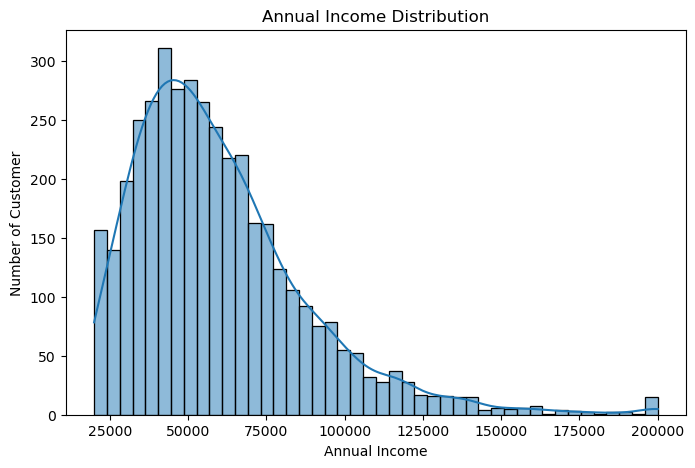

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Annual_Income"], kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customer")

plt.show()

### 🛒 Monthly Spending Distribution

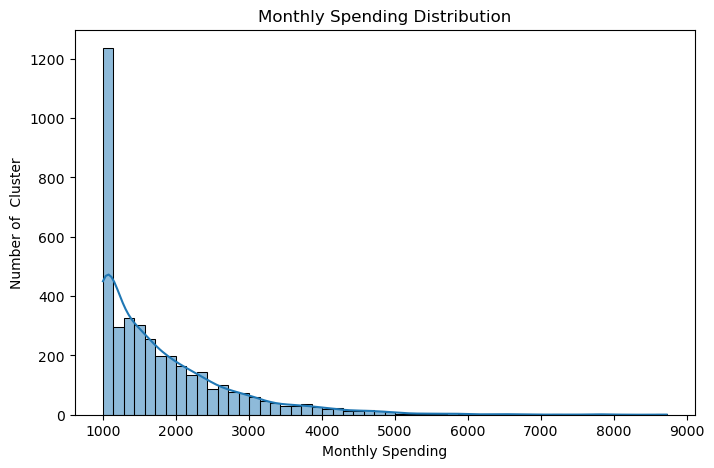

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Monthly_Spending"], kde=True)

plt.title("Monthly Spending Distribution")
plt.xlabel("Monthly Spending")
plt.ylabel("Number of  Cluster")

plt.show()

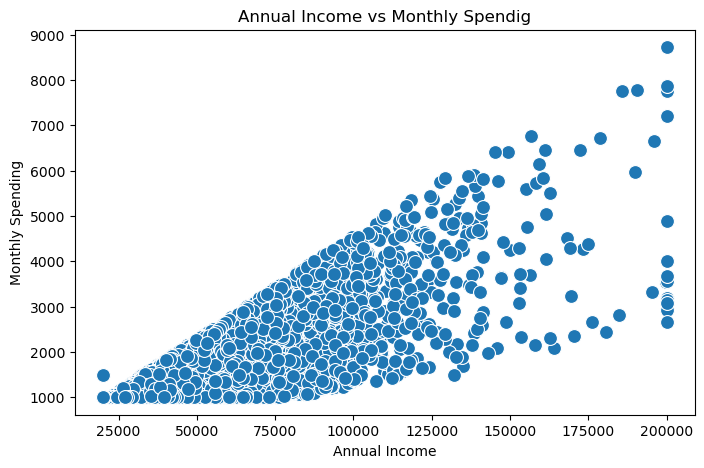

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Annual_Income", y="Monthly_Spending", s=100)

plt.title("Annual Income vs Monthly Spendig")
plt.xlabel("Annual Income")
plt.ylabel("Monthly Spending")

plt.show()

## 🎯 Feature Selection

The following financial and behavioural features are selected for customer segmentation:

- Annual Income
- Account Balance
- Transactions Per Month
- Loan Amount
- Monthly Spending

These features represent important aspects of customer financial behaviour.

In [15]:
features =["Annual_Income",
          "Account_Balance",
          "Transactions_Per_Month",
          "Loan_Amount",
          "Monthly_Spending"
          ]
x =df[features]
x.head()

,Annual_Income,Account_Balance,Transactions_Per_Month,Loan_Amount,Monthly_Spending
0,93246,9693.0,10,27395,4027.0
1,64954,15072.0,18,31747,2078.0
2,52407,11264.0,25,9839,2017.0
3,67276,14949.0,9,16051,2530.0
4,27125,2563.0,22,11396,1000.0


## ⚖️ Feature Scaling

The selected features have different numerical ranges.

StandardScaler is used to standardize the features before applying K-Means clustering.

This ensures that features with larger numerical values do not dominate the clustering process.

In [16]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

x_scaled[:5]

array([[ 1.1743396 , -0.53224237, -1.18110677,  0.64188954,  2.38118611],
       [ 0.17192845,  0.04931525, -0.01288693,  0.94867297,  0.3068452 ],
       [-0.2726231 , -0.36239165,  1.00930544, -0.59567708,  0.24192227],
       [ 0.25419901,  0.03601695, -1.32713425, -0.15777757,  0.78791349],
       [-1.16838723, -1.30311166,  0.571223  , -0.48592023, -0.84048138]])

## 🔎 Finding the Optimal Number of Clusters

The appropriate number of clusters needs to be determined before applying K-Means.

Two evaluation techniques are used:

1. Elbow Method
2. Silhouette Score

In [17]:
inertia =[]

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

### 📉 Elbow Method

The Elbow Method evaluates different values of K using Within-Cluster Sum of Squares (WCSS).

The point where the reduction in WCSS begins to slow down indicates a suitable number of clusters.

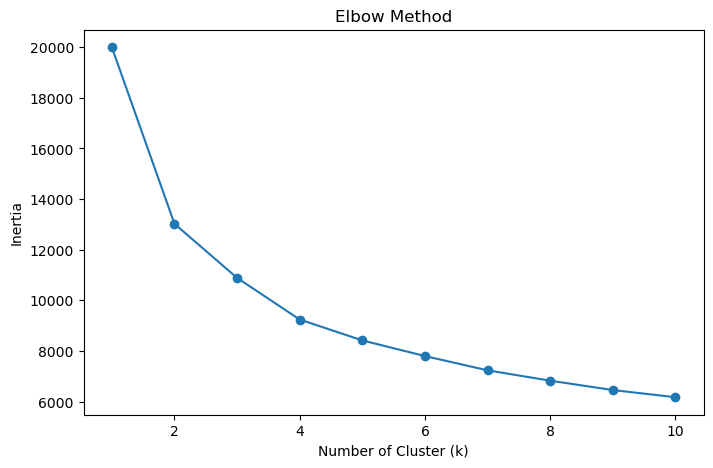

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Cluster (k)")
plt.ylabel("Inertia")

plt.show()

### 📊 Silhouette Score

Silhouette Score is used to evaluate how well customers are separated into clusters.

A higher score generally indicates better-defined clusters.

In [19]:
silhouette_scores = []

for k in range(2, 11):

    kmeans_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans_test.fit_predict(x_scaled)

    score = silhouette_score(
        x_scaled,
        labels
    )

    silhouette_scores.append(score)


# Display scores

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k} → Silhouette Score = {score:.3f}")

K = 2 → Silhouette Score = 0.389
K = 3 → Silhouette Score = 0.266
K = 4 → Silhouette Score = 0.217
K = 5 → Silhouette Score = 0.220
K = 6 → Silhouette Score = 0.200
K = 7 → Silhouette Score = 0.195
K = 8 → Silhouette Score = 0.194
K = 9 → Silhouette Score = 0.183
K = 10 → Silhouette Score = 0.177


# 🤖 K-Means Clustering

K-Means Clustering is an unsupervised machine learning algorithm used to divide customers into groups based on similarity.

The selected customer features are used to train the K-Means model.

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["cluster"] = kmeans.fit_predict(x_scaled)

In [21]:
df.head(10)

,Customer_ID,Age,Annual_Income,Account_Balance,Credit_Score,Transactions_Per_Month,Loan_Amount,Monthly_Spending,cluster
0,1001,56,93246,9693.0,672.0,10,27395,4027.0,2
1,1002,69,64954,15072.0,738.0,18,31747,2078.0,2
2,1003,46,52407,11264.0,631.0,25,9839,2017.0,0
3,1004,32,67276,14949.0,659.0,9,16051,2530.0,2
4,1005,60,27125,2563.0,670.0,22,11396,1000.0,0
5,1006,25,33125,6483.0,580.0,34,18192,1000.0,0
6,1007,38,32139,10351.0,772.0,25,1692,1000.0,0
7,1008,56,58654,11617.0,630.0,28,30317,1000.0,2
8,1009,36,119937,37043.0,708.0,20,57067,2688.0,1
9,1010,40,150117,29758.0,675.0,25,28421,4248.0,1


In [22]:
df["cluster"].value_counts().sort_index()

cluster
0    2253
1     324
2    1423
Name: count, dtype: int64

## 🔬 Cluster Analysis

After applying K-Means clustering, the average characteristics of each cluster are analysed.

This helps understand how the customer groups differ in terms of income, account balance, transactions, loan amount, and monthly spending.

### 📋 Average Customer Characteristics by Cluster

In [23]:
cluster_summary = df.groupby("cluster")[features].mean()
cluster_summary

,Annual_Income,Account_Balance,Transactions_Per_Month,Loan_Amount,Monthly_Spending
cluster,,,,,
0,42328.907235,9522.693964,17.739458,11421.027963,1282.740790
1,122513.166667,33496.359568,17.219136,41055.145062,3854.484568
2,74030.011947,18380.902319,18.838370,23979.919888,2122.217147


## 👥 Customer Segment Interpretation

Based on the average financial and behavioural characteristics of each cluster, customer segments can be interpreted.

### High Value Customers
Customers with relatively higher income, account balance, transaction activity, and spending.

### Low Activity Customers
Customers with relatively lower transaction activity and lower financial engagement.

### Medium Value Customers
Customers showing moderate financial and transactional activity.

> Note: Segment names are assigned based on the observed characteristics of the generated clusters.

In [24]:
cluster_name = {0 : "High Value Customers",
                1 : "Low Activity Customers",
                2 : "Medium Value Customers"
               }
df["Customer_Segment"] = df["cluster"].map(cluster_name)

In [25]:
df.head()

,Customer_ID,Age,Annual_Income,Account_Balance,Credit_Score,Transactions_Per_Month,Loan_Amount,Monthly_Spending,cluster,Customer_Segment
0,1001,56,93246,9693.0,672.0,10,27395,4027.0,2,Medium Value Customers
1,1002,69,64954,15072.0,738.0,18,31747,2078.0,2,Medium Value Customers
2,1003,46,52407,11264.0,631.0,25,9839,2017.0,0,High Value Customers
3,1004,32,67276,14949.0,659.0,9,16051,2530.0,2,Medium Value Customers
4,1005,60,27125,2563.0,670.0,22,11396,1000.0,0,High Value Customers


## 📊 Final Cluster Visualization

The final visualization shows the distribution of customers across the generated clusters.

This helps visually compare the identified customer groups.

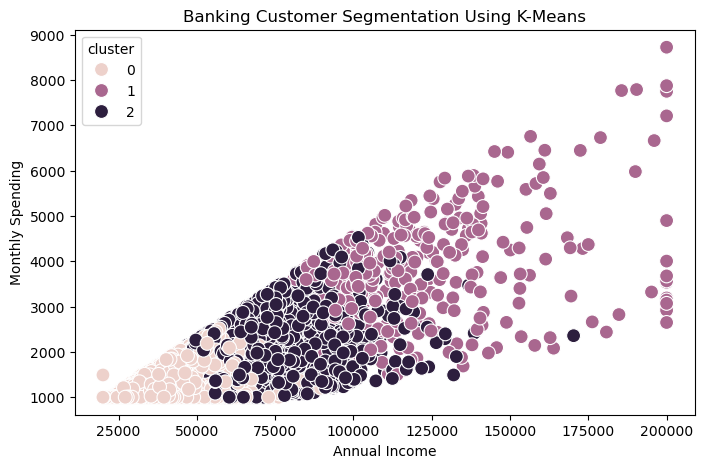

In [26]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Annual_Income", y="Monthly_Spending", hue="cluster", s=100)

plt.title("Banking Customer Segmentation Using K-Means")
plt.xlabel("Annual Income")
plt.ylabel("Monthly Spending")

plt.show()

## 💾 Save Clustered Dataset

The customer segmentation results are saved as a CSV file for further analysis and use in the Streamlit application.

In [27]:
df.to_csv("../Data/Banking_Segmentation_Result.csv", index=False)

## 💾 Save Trained Model

The trained K-Means model and StandardScaler are saved using Joblib.

These saved files can be reused in the Streamlit application to predict the segment of new customers.

In [28]:
joblib.dump(kmeans, "../Model/K-Means_Model.pkl")

['../Model/K-Means_Model.pkl']

In [29]:
joblib.dump(scaler, "../Model/Scaler.pkl")

['../Model/Scaler.pkl']

# ✅ Conclusion

In this project, K-Means Clustering was used to segment banking customers based on their financial and behavioural characteristics.

The project included:

- Data understanding
- Data quality checking
- Exploratory Data Analysis
- Feature selection
- Feature scaling
- Optimal cluster selection
- K-Means clustering
- Cluster analysis
- Customer segment interpretation
- Model saving

The resulting customer segments can be used to better understand customer behaviour and support data-driven banking decisions.